In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/obesity.csv')
df

,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Male,52,1.586572,127.722219,yes,no,2.0,1.0,Sometimes,no,3.0,no,2.0,0.0,Frequently,Public_Transportation,Obesity_Type_III
1,Female,42,1.695190,128.079110,yes,yes,1.0,1.0,Sometimes,no,1.0,no,0.0,1.0,no,Public_Transportation,Obesity_Type_III
2,Female,28,1.910184,88.505940,yes,yes,2.0,2.0,Sometimes,no,3.0,yes,0.0,1.0,no,Public_Transportation,Normal_Weight
3,Male,56,1.835400,162.419958,yes,no,1.0,4.0,no,no,1.0,no,0.0,2.0,no,Public_Transportation,Obesity_Type_III
4,Female,21,1.843634,61.756414,no,yes,3.0,4.0,no,yes,2.0,no,1.0,0.0,Always,Automobile,Insufficient_Weight
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,23,1.876339,135.669653,no,no,1.0,3.0,Always,no,1.0,no,0.0,0.0,Always,Motorbike,Obesity_Type_II
2107,Male,64,1.829003,75.762855,no,yes,3.0,4.0,Sometimes,no,3.0,no,3.0,0.0,no,Automobile,Normal_Weight
2108,Female,48,1.764374,123.084020,no,no,2.0,3.0,Sometimes,no,1.0,no,2.0,0.0,Sometimes,Automobile,Obesity_Type_II
2109,Male,42,1.478274,84.325057,no,yes,2.0,4.0,Always,no,2.0,no,2.0,2.0,Frequently,Public_Transportation,Obesity_Type_II


In [ ]:
df['NObeyesdad'].value_counts()

,count
NObeyesdad,
Obesity_Type_III,804
Normal_Weight,334
Obesity_Type_I,279
Insufficient_Weight,243
Obesity_Type_II,224
Overweight_Level_II,126
Overweight_Level_I,101


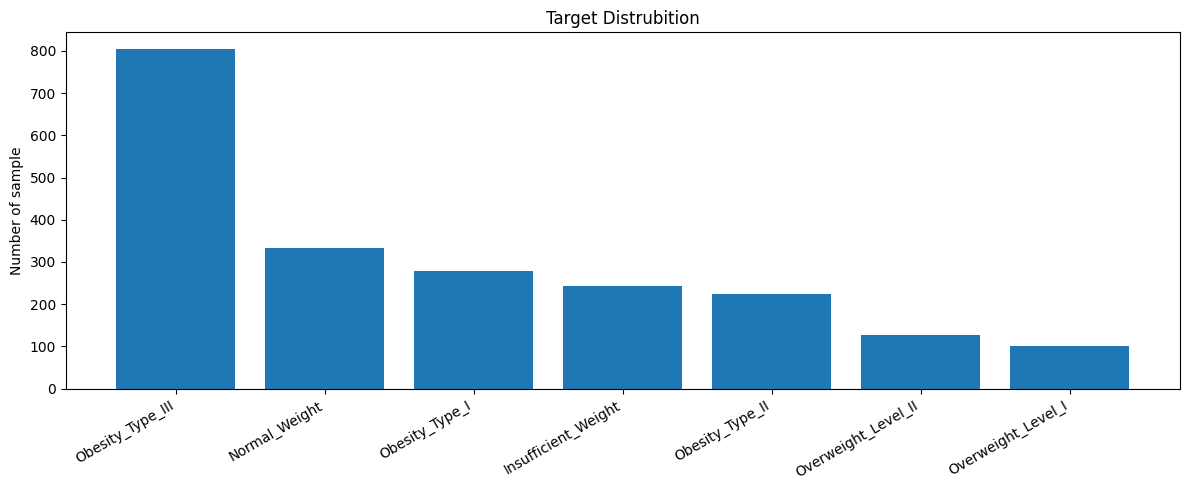

In [ ]:
class_order = ['Obesity_Type_III', 'Normal_Weight', 'Obesity_Type_I',
                'Insufficient_Weight', 'Obesity_Type_II', 'Overweight_Level_II', 'Overweight_Level_I']

counts = df['NObeyesdad'].value_counts().reindex(class_order)

plt.figure(figsize = (12, 5))
bars = plt.bar(class_order, counts.values, linewidth = 2)
plt.xticks(rotation = 30, ha = 'right')
plt.title('Target Distrubition')
plt.ylabel('Number of sample')
plt.tight_layout()
plt.show()

In [ ]:
df_enc = df.copy()
cat_cols = df.select_dtypes(include = 'object').columns.drop('NObeyesdad')
cat_cols

Index(['Gender', 'family_history_with_overweight', 'FAVC', 'CAEC', 'SMOKE',
       'SCC', 'CALC', 'MTRANS'],
      dtype='object')

In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

le_dict = {}
for col in cat_cols:
    le = LabelEncoder()
    df_enc[col] = le.fit_transform(df[col])
    le_dict = le

le_target = LabelEncoder()
df_enc['NObeyesdad'] = le_target.fit_transform(df['NObeyesdad'])

for i, c in enumerate(le_target.classes_):
    print(f'{i} -> {c}')

0 -> Insufficient_Weight
1 -> Normal_Weight
2 -> Obesity_Type_I
3 -> Obesity_Type_II
4 -> Obesity_Type_III
5 -> Overweight_Level_I
6 -> Overweight_Level_II


In [ ]:
X = df_enc.drop('NObeyesdad', axis = 1)
y = df_enc['NObeyesdad']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2,
                                                    random_state = 42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.multiclass import OneVsRestClassifier, OneVsOneClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

lr_base = LogisticRegression(max_iter=1000, random_state=42)
ovr_clf = OneVsRestClassifier(lr_base)
ovr_clf.fit(X_train, y_train)

print(len(ovr_clf.estimators_))

y_pred_ovr = ovr_clf.predict(X_test)
acc_ovr = accuracy_score(y_test, y_pred_ovr)
print(f'OvR Accuracy: {acc_ovr:.4f}')

7
OvR Accuracy: 0.7045


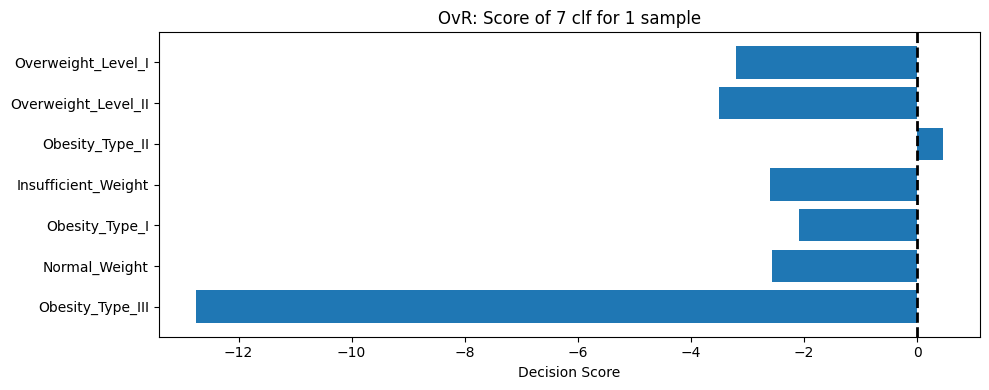

Predict: Obesity_Type_III
Actual: Obesity_Type_III


In [ ]:
sample_idx = 0
sample = X_test[sample_idx: sample_idx + 1]
scores = ovr_clf.decision_function(sample)[0]

plt.figure(figsize = (10, 4))
plt.barh(class_order, scores)
plt.axvline(0, color = 'black', linewidth  = 2, linestyle = '--')
plt.title('OvR: Score of 7 clf for 1 sample')
plt.xlabel('Decision Score')
pred_class = le_target.classes_[np.argmax(scores)]
true_class = le_target.classes_[y_test.iloc[sample_idx]]
plt.tight_layout()
plt.show()

print(f'Predict: {pred_class}')
print(f'Actual: {true_class}')

In [ ]:
ovo_clf = OneVsOneClassifier(LogisticRegression(max_iter = 1000, random_state = 42))

ovo_clf.fit(X_train, y_train)

n_classes = len(le_target.classes_)
n_classifier = n_classes * (n_classes - 1) // 2
print(f'Number of OvO classifires: {len(ovo_clf.estimators_)}')
print(f'Number of classes: {n_classes}')

Number of OvO classifires: 21
Number of classes: 7


In [ ]:
y_pred_ovo = ovo_clf.predict(X_test)
acc_ovo = accuracy_score(y_test, y_pred_ovo)
print(f'OvO Accuracy: {acc_ovo:.4f}')

OvO Accuracy: 0.9054


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

rf_clf = RandomForestClassifier(n_estimators = 100, random_state = 42)
rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)


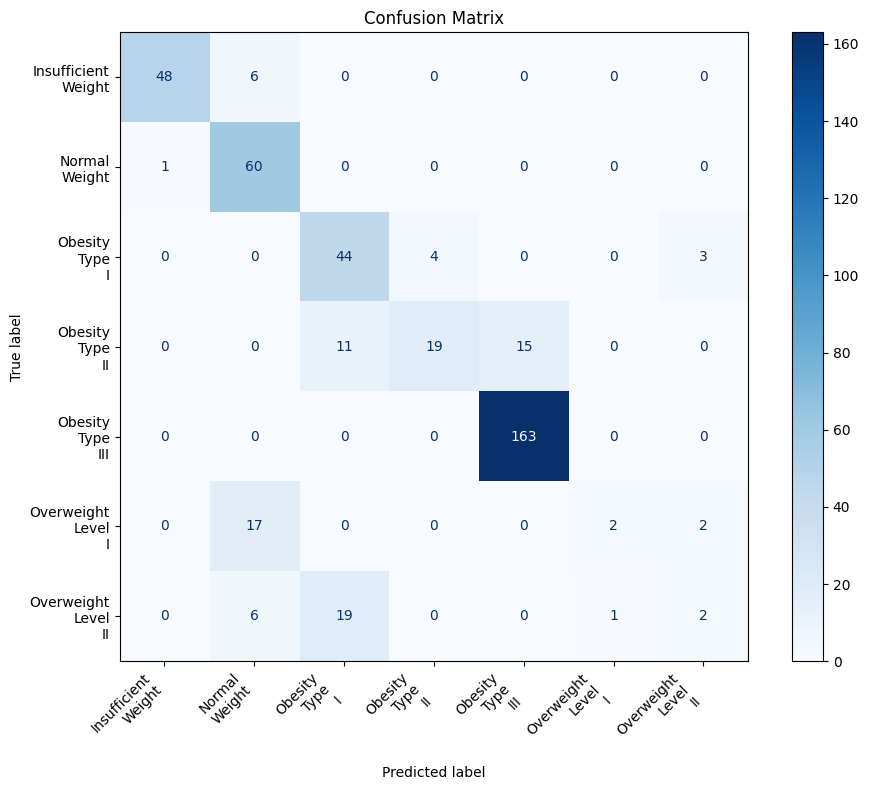

In [ ]:
cm = confusion_matrix(y_test, y_pred_rf)
class_names = [c.replace('_', '\n') for c in le_target.classes_]
fig, ax = plt.subplots(figsize = (10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix = cm,
                              display_labels = class_names
                              )
disp.plot(ax = ax, colorbar = True, cmap = 'Blues')
ax.set_title('Confusion Matrix')
plt.xticks(rotation = 45, ha = 'right')
plt.tight_layout()
plt.show()

In [ ]:
report = classification_report(y_test, y_pred_rf)
print(report)

              precision    recall  f1-score   support

           0       0.98      0.89      0.93        54
           1       0.67      0.98      0.80        61
           2       0.59      0.86      0.70        51
           3       0.83      0.42      0.56        45
           4       0.92      1.00      0.96       163
           5       0.67      0.10      0.17        21
           6       0.29      0.07      0.11        28

    accuracy                           0.80       423
   macro avg       0.71      0.62      0.60       423
weighted avg       0.79      0.80      0.76       423

